# ASCON First-Round DPA Trace Collection

This notebook flashes the new `simpleserial-ascon-firstround-dpa` firmware, then collects fixed-key/random-nonce traces for the ASCON first initialization round.

**Important:** this firmware uses:

```python
target.simpleserial_write('p', bytearray([]))
```

There is **no byte loop** and no target byte argument.


## 0. Expected locations

Save this notebook here:

```text
C:\Users\thetp\Downloads\ASCON_FYP\02_Notebooks\ASCON_FirstRound_DPA_Trace_Collection.ipynb
```

Data will be saved under:

```text
C:\Users\thetp\Downloads\ASCON_FYP\03_Data\first_round_dpa\...
```

Firmware expected at:

```text
C:\Users\thetp\Downloads\ASCON_FYP\01_Firmware\first_round_dpa\simpleserial-ascon-firstround-dpa\simpleserial-ascon-firstround-dpa-CWLITEXMEGA.hex
```


In [1]:
# 1. Imports and paths

import os
import json
import time
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import chipwhisperer as cw

PROJECT_ROOT = Path(r"C:\Users\thetp\Downloads\ASCON_FYP")

FW_PATH = PROJECT_ROOT / r"01_Firmware\first_round_dpa\simpleserial-ascon-firstround-dpa\simpleserial-ascon-firstround-dpa-CWLITEXMEGA.hex"

DATA_BASE = PROJECT_ROOT / r"03_Data\first_round_dpa"

FIXED_KEY_HEX = "00112233445566778899aabbccddeeff"
FIXED_KEY = bytes.fromhex(FIXED_KEY_HEX)

print("Firmware path:", FW_PATH)
print("Firmware exists:", FW_PATH.exists())
print("Data base:", DATA_BASE)

assert FW_PATH.exists(), "Firmware .hex file not found. Check FW_PATH."
DATA_BASE.mkdir(parents=True, exist_ok=True)


C:\Users\thetp\anaconda3\envs\cw\lib\site-packages\chipwhisperer\capture\trace\TraceWhisperer.py:31: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources # type: ignore


Firmware path: C:\Users\thetp\Downloads\ASCON_FYP\01_Firmware\first_round_dpa\simpleserial-ascon-firstround-dpa\simpleserial-ascon-firstround-dpa-CWLITEXMEGA.hex
Firmware exists: True
Data base: C:\Users\thetp\Downloads\ASCON_FYP\03_Data\first_round_dpa


In [2]:
# 2. Connect to ChipWhisperer

# If you already have an open connection from another notebook/cell, this tries to close it cleanly.
try:
    scope.dis()
except Exception:
    pass

try:
    target.dis()
except Exception:
    pass

scope = cw.scope()
target = cw.target(scope)

print("Connected to scope and target.")
print(scope)


Connected to scope and target.
cwlite Device
sn         = 50203220594a48303230343239313036
fw_version = 
    major = 0
    minor = 65
    debug = 0
gain = 
    mode = low
    gain = 0
    db   = 5.5
adc = 
    state          = False
    basic_mode     = low
    timeout        = 2
    offset         = 0
    presamples     = 0
    samples        = 24400
    decimate       = 1
    trig_count     = 17908637
    fifo_fill_mode = normal
clock = 
    adc_src       = clkgen_x1
    adc_phase     = 0
    adc_freq      = 96000000
    adc_rate      = 96000000.0
    adc_locked    = True
    freq_ctr      = 0
    freq_ctr_src  = extclk
    clkgen_src    = system
    extclk_freq   = 10000000
    clkgen_mul    = 2
    clkgen_div    = 1
    clkgen_freq   = 192000000.0
    clkgen_locked = True
trigger = 
    triggers = tio4
    module   = basic
io = 
    tio1         = serial_tx
    tio2         = serial_rx
    tio3         = high_z
    tio4         = high_z
    pdid         = high_z
    pdic         = 

In [3]:
# 3. Scope settings

# Use settings close to your previous stable ASCON/XMEGA setup.
# You can adjust samples/gain later after checking the smoke-test trace.

scope.gain.db = 45
scope.adc.samples = 5000
scope.adc.offset = 0
scope.adc.basic_mode = "rising_edge"

scope.clock.clkgen_freq = 7.37e6
scope.clock.adc_src = "clkgen_x4"

scope.trigger.triggers = "tio4"

scope.io.tio1 = "serial_rx"
scope.io.tio2 = "serial_tx"
scope.io.hs2 = "clkgen"

scope.adc.timeout = 2

print("Scope configured.")
print("ADC samples:", scope.adc.samples)
print("Gain:", scope.gain.db)
print("Clock:", scope.clock.clkgen_freq)
print("ADC source:", scope.clock.adc_src)
print("Trigger:", scope.trigger.triggers)


Scope configured.
ADC samples: 5000
Gain: 44.81640625
Clock: 7384615.384615385
ADC source: clkgen_x4
Trigger: tio4


In [4]:
# 4. Flash/program the XMEGA firmware
#
# Run this cell before any collection.
# The collection functions below also allow flashing immediately before collection.

def flash_firmware():
    print("Flashing firmware:")
    print(FW_PATH)
    cw.program_target(scope, cw.programmers.XMEGAProgrammer, str(FW_PATH))
    time.sleep(0.5)
    target.flush()
    print("Firmware programmed and target flushed.")

flash_firmware()
FIRMWARE_PROGRAMMED = True


Flashing firmware:
C:\Users\thetp\Downloads\ASCON_FYP\01_Firmware\first_round_dpa\simpleserial-ascon-firstround-dpa\simpleserial-ascon-firstround-dpa-CWLITEXMEGA.hex
XMEGA Programming flash...
XMEGA Reading flash...
Verified flash OK, 12105 bytes
Firmware programmed and target flushed.


capture_ret: False
response: 13
nonce: 758f55ce6109cfe3b225304b13a6448c
trace length: 5000
trace min/max: -0.5 0.4990234375
trigger_count: 10880


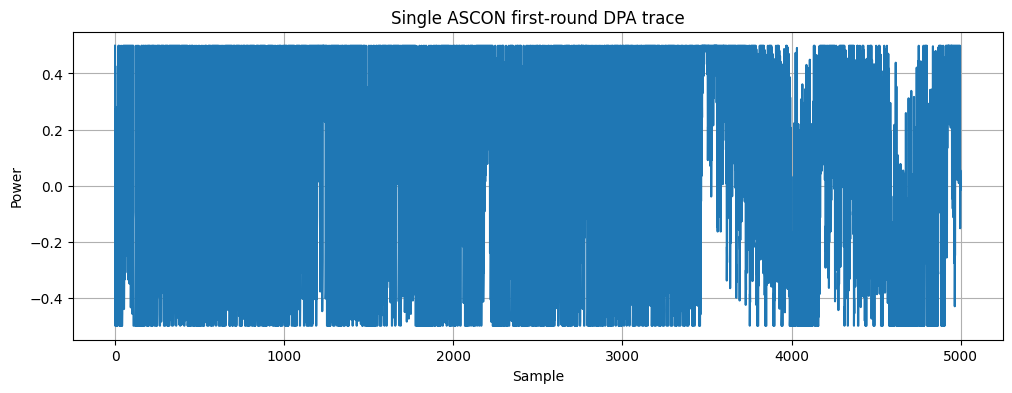

In [5]:
# 5. SimpleSerial sanity test
#
# Expected:
# - capture_ret = False
# - response is not empty
# - trace is not flat
# - trigger_count is stable/reasonable

assert "FIRMWARE_PROGRAMMED" in globals() and FIRMWARE_PROGRAMMED, "Run the flash/programming cell first."

nonce = os.urandom(16)

target.flush()

target.simpleserial_write('k', bytearray(FIXED_KEY))
time.sleep(0.05)

target.simpleserial_write('n', bytearray(nonce))
time.sleep(0.05)

scope.arm()
target.simpleserial_write('p', bytearray([]))   # IMPORTANT: no payload for first-round DPA firmware

capture_ret = scope.capture()
resp = target.simpleserial_read('r', 1, timeout=1000)
trace = scope.get_last_trace()

print("capture_ret:", capture_ret)
print("response:", resp.hex() if resp else None)
print("nonce:", nonce.hex())
print("trace length:", len(trace))
print("trace min/max:", float(np.min(trace)), float(np.max(trace)))

try:
    print("trigger_count:", scope.adc.trig_count)
except Exception as e:
    print("trigger_count unavailable:", e)

plt.figure(figsize=(12, 4))
plt.plot(trace)
plt.title("Single ASCON first-round DPA trace")
plt.xlabel("Sample")
plt.ylabel("Power")
plt.grid(True)
plt.show()


In [6]:
# 6. Trace collection function
#
# This flashes before collection by default to make sure the correct firmware is loaded.

def collect_first_round_traces(
    n_traces,
    run_prefix,
    flash_before_collection=True,
    save_every=1000
):
    if flash_before_collection:
        flash_firmware()

    target.flush()

    # Load fixed key once.
    target.simpleserial_write('k', bytearray(FIXED_KEY))
    time.sleep(0.05)

    run_name = run_prefix + "_" + datetime.now().strftime("%Y%m%d_%H%M%S")
    out_dir = DATA_BASE / run_name
    out_dir.mkdir(parents=True, exist_ok=True)

    traces = []
    metadata = []

    print("Output folder:", out_dir)
    print("Number of traces:", n_traces)
    print("Fixed key:", FIXED_KEY_HEX)
    print("Starting collection...")

    start_time = time.time()

    for i in range(n_traces):
        nonce = os.urandom(16)

        target.simpleserial_write('n', bytearray(nonce))
        time.sleep(0.002)

        scope.arm()
        target.simpleserial_write('p', bytearray([]))  # no payload

        ret = scope.capture()
        resp = target.simpleserial_read('r', 1, timeout=1000)
        trace = scope.get_last_trace()

        if trace is None:
            trace = np.full(scope.adc.samples, np.nan, dtype=np.float32)
        else:
            trace = np.asarray(trace, dtype=np.float32)

        try:
            trig_count = scope.adc.trig_count
        except Exception:
            trig_count = None

        traces.append(trace)

        metadata.append({
            "trace_index": i,
            "key_hex": FIXED_KEY_HEX,
            "nonce_hex": nonce.hex(),
            "response_hex": resp.hex() if resp else "",
            "capture_ret": bool(ret),
            "trigger_count": trig_count,
        })

        if (i + 1) % save_every == 0:
            elapsed = time.time() - start_time
            print(f"{i + 1}/{n_traces} traces collected | elapsed {elapsed:.1f}s")

    traces = np.asarray(traces, dtype=np.float32)
    metadata_df = pd.DataFrame(metadata)

    np.save(out_dir / "traces.npy", traces)
    metadata_df.to_csv(out_dir / "metadata.csv", index=False)

    config = {
        "experiment": "ASCON first-round DPA fixed-key random-nonce trace collection",
        "firmware_path": str(FW_PATH),
        "firmware_file": FW_PATH.name,
        "data_base": str(DATA_BASE),
        "fixed_key_hex": FIXED_KEY_HEX,
        "nonce_mode": "random 16-byte nonce per trace",
        "num_traces": int(n_traces),
        "p_command_payload": "empty bytearray",
        "scope_gain_db": float(scope.gain.db),
        "scope_adc_samples": int(scope.adc.samples),
        "scope_adc_offset": int(scope.adc.offset),
        "scope_adc_basic_mode": str(scope.adc.basic_mode),
        "scope_clkgen_freq": float(scope.clock.clkgen_freq),
        "scope_adc_src": str(scope.clock.adc_src),
        "trigger": str(scope.trigger.triggers),
        "created_at": datetime.now().isoformat(),
        "notes": (
            "Fixed key + random nonce. Trigger is inside ascon_first_round_dpa_capture(), "
            "around the first ASCON initialization ROUND(s, 0xf0). No byte loop."
        )
    }

    with open(out_dir / "config.json", "w") as f:
        json.dump(config, f, indent=4)

    print("\nSaved:")
    print("traces:", out_dir / "traces.npy")
    print("metadata:", out_dir / "metadata.csv")
    print("config:", out_dir / "config.json")

    print("\nBasic checks:")
    print("traces shape:", traces.shape)
    print("capture_ret counts:")
    print(metadata_df["capture_ret"].value_counts(dropna=False))
    print("empty responses:", int((metadata_df["response_hex"] == "").sum()))
    print("unique nonces:", metadata_df["nonce_hex"].nunique())
    print("trigger_count counts:")
    print(metadata_df["trigger_count"].value_counts(dropna=False).head())

    return traces, metadata_df, out_dir


In [7]:
# 7. Smoke test collection: 100 traces first
#
# Run this before collecting 30,000 traces.

smoke_traces, smoke_metadata, smoke_out_dir = collect_first_round_traces(
    n_traces=100,
    run_prefix="smoketest_ascon_firstround_fixedkey_randomnonce",
    flash_before_collection=True,
    save_every=20
)

print("Smoke test saved to:", smoke_out_dir)


Flashing firmware:
C:\Users\thetp\Downloads\ASCON_FYP\01_Firmware\first_round_dpa\simpleserial-ascon-firstround-dpa\simpleserial-ascon-firstround-dpa-CWLITEXMEGA.hex
XMEGA Programming flash...
XMEGA Reading flash...
Verified flash OK, 12105 bytes
Firmware programmed and target flushed.
Output folder: C:\Users\thetp\Downloads\ASCON_FYP\03_Data\first_round_dpa\smoketest_ascon_firstround_fixedkey_randomnonce_20260612_051120
Number of traces: 100
Fixed key: 00112233445566778899aabbccddeeff
Starting collection...
20/100 traces collected | elapsed 2.7s
40/100 traces collected | elapsed 5.4s
60/100 traces collected | elapsed 8.2s
80/100 traces collected | elapsed 10.9s
100/100 traces collected | elapsed 13.6s

Saved:
traces: C:\Users\thetp\Downloads\ASCON_FYP\03_Data\first_round_dpa\smoketest_ascon_firstround_fixedkey_randomnonce_20260612_051120\traces.npy
metadata: C:\Users\thetp\Downloads\ASCON_FYP\03_Data\first_round_dpa\smoketest_ascon_firstround_fixedkey_randomnonce_20260612_051120\metad

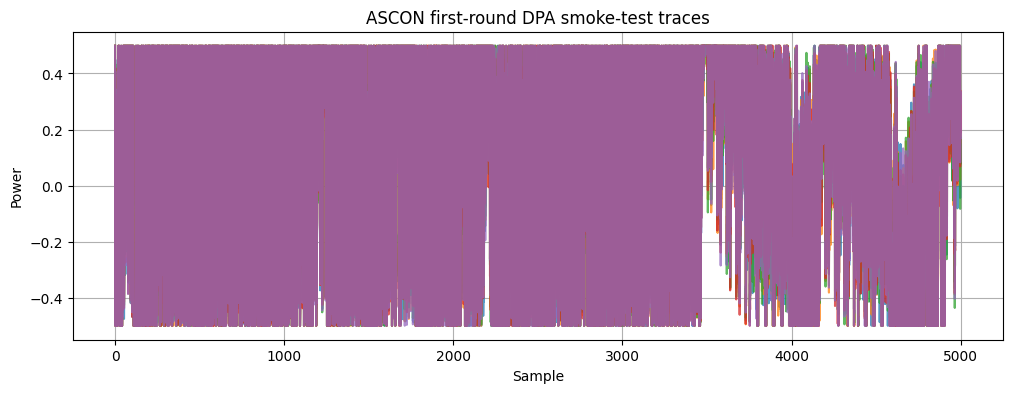

Smoke metadata preview:


,trace_index,key_hex,nonce_hex,response_hex,capture_ret,trigger_count
0,0,00112233445566778899aabbccddeeff,0faa1ba1ccbb93d83a790eac853a1e6b,3d,False,10880
1,1,00112233445566778899aabbccddeeff,e05605ecc33b60696e16033cd9ffcc49,39,False,10880
2,2,00112233445566778899aabbccddeeff,03917675473fe4b5cae9fc2cb6a32997,1e,False,10880
3,3,00112233445566778899aabbccddeeff,fc0b27f83b71efa3665b97c2e1ba015e,cc,False,10880
4,4,00112233445566778899aabbccddeeff,d6268d79c4768a5ec5085436b0b56b78,dd,False,10880


In [8]:
# 8. Plot smoke-test traces

plt.figure(figsize=(12, 4))
for i in range(min(5, len(smoke_traces))):
    plt.plot(smoke_traces[i], alpha=0.75)

plt.title("ASCON first-round DPA smoke-test traces")
plt.xlabel("Sample")
plt.ylabel("Power")
plt.grid(True)
plt.show()

print("Smoke metadata preview:")
display(smoke_metadata.head())


In [9]:
# 9. Full collection: 30,000 traces
#
# Run this only after the 100-trace smoke test looks good.
# It will flash the firmware again before collecting.

FULL_N_TRACES = 30000

full_traces, full_metadata, full_out_dir = collect_first_round_traces(
    n_traces=FULL_N_TRACES,
    run_prefix="ascon_firstround_fixedkey_randomnonce",
    flash_before_collection=True,
    save_every=1000
)

print("Full dataset saved to:", full_out_dir)


Flashing firmware:
C:\Users\thetp\Downloads\ASCON_FYP\01_Firmware\first_round_dpa\simpleserial-ascon-firstround-dpa\simpleserial-ascon-firstround-dpa-CWLITEXMEGA.hex
XMEGA Programming flash...
XMEGA Reading flash...
Verified flash OK, 12105 bytes
Firmware programmed and target flushed.
Output folder: C:\Users\thetp\Downloads\ASCON_FYP\03_Data\first_round_dpa\ascon_firstround_fixedkey_randomnonce_20260612_051138
Number of traces: 30000
Fixed key: 00112233445566778899aabbccddeeff
Starting collection...
1000/30000 traces collected | elapsed 135.3s
2000/30000 traces collected | elapsed 269.7s
3000/30000 traces collected | elapsed 405.1s
4000/30000 traces collected | elapsed 540.9s
5000/30000 traces collected | elapsed 676.5s
6000/30000 traces collected | elapsed 811.8s
7000/30000 traces collected | elapsed 947.1s
8000/30000 traces collected | elapsed 1083.3s
9000/30000 traces collected | elapsed 1218.4s
10000/30000 traces collected | elapsed 1354.1s
11000/30000 traces collected | elapsed 1

Full traces shape: (30000, 5000)
Capture return counts:
capture_ret
False    30000
Name: count, dtype: int64

Empty responses: 0
Unique nonces: 30000

Trigger count counts:
trigger_count
10880    30000
Name: count, dtype: int64


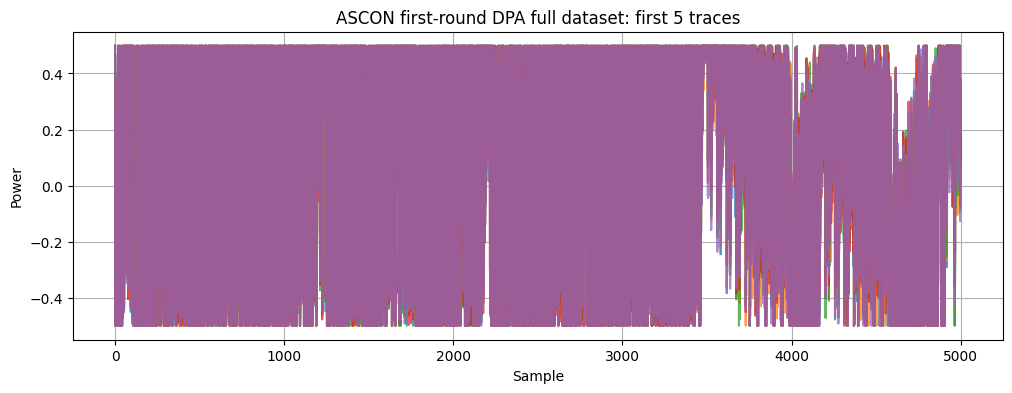

In [10]:
# 10. Final full-dataset checks

print("Full traces shape:", full_traces.shape)
print("Capture return counts:")
print(full_metadata["capture_ret"].value_counts(dropna=False))

print("\nEmpty responses:", int((full_metadata["response_hex"] == "").sum()))
print("Unique nonces:", full_metadata["nonce_hex"].nunique())

print("\nTrigger count counts:")
print(full_metadata["trigger_count"].value_counts(dropna=False).head(10))

plt.figure(figsize=(12, 4))
for i in range(5):
    plt.plot(full_traces[i], alpha=0.75)

plt.title("ASCON first-round DPA full dataset: first 5 traces")
plt.xlabel("Sample")
plt.ylabel("Power")
plt.grid(True)
plt.show()


## Next step after collection

After the full dataset is saved, use the output folder containing:

```text
traces.npy
metadata.csv
config.json
```

for the paper-style x0/x1 CPA/DPA analysis.

Do not use byte-wise labels for this dataset. This is a fixed-key/random-nonce classical DPA/CPA baseline dataset.


traces shape: (30000, 5000)
metadata shape: (30000, 6)
capture_ret counts:
capture_ret
False    30000
Name: count, dtype: int64
unique nonces: 30000
trigger_count counts:
trigger_count
10880    30000
Name: count, dtype: int64
sample min: -0.5
sample max: 0.49902344
overall clipping fraction: 0.3867642
median clipping per trace: 0.3867642


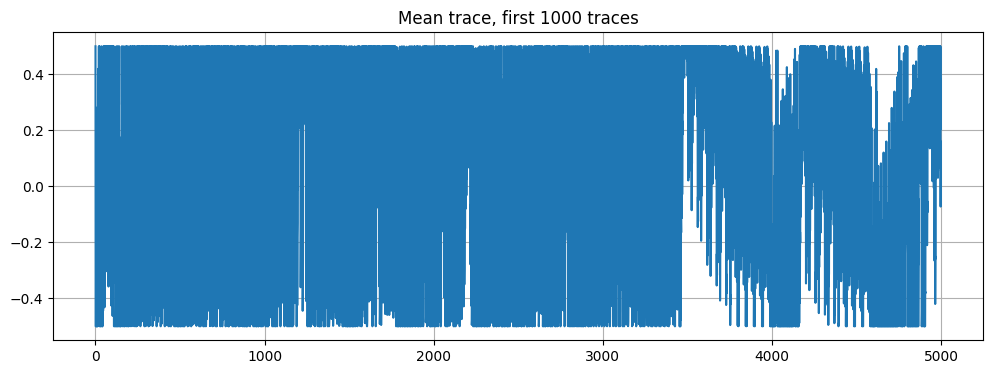

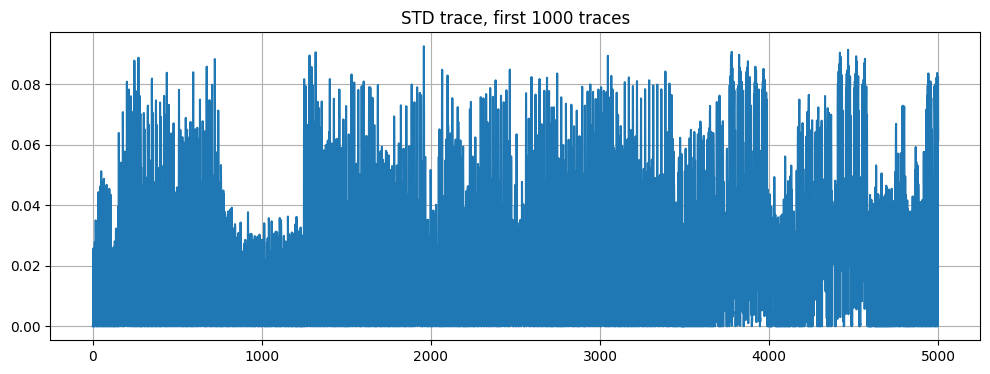

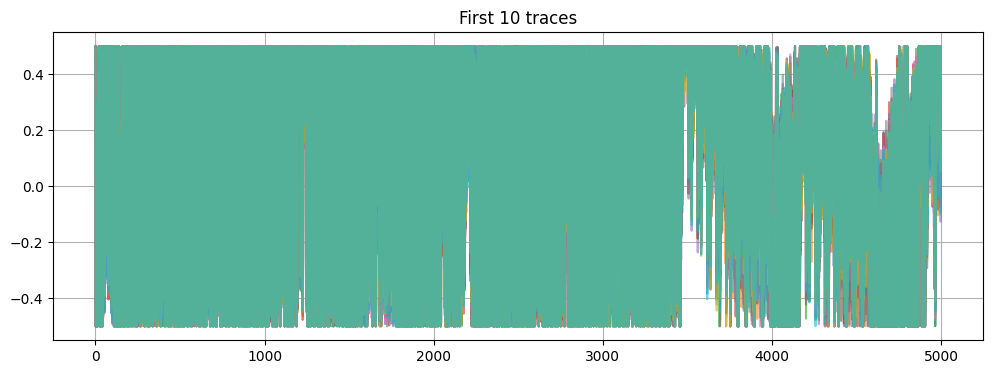

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

run_dir = Path(r"C:\Users\thetp\Downloads\ASCON_FYP\03_Data\first_round_dpa\ascon_firstround_fixedkey_randomnonce_20260612_051138")

traces = np.load(run_dir / "traces.npy", mmap_mode="r")
metadata = pd.read_csv(run_dir / "metadata.csv")

print("traces shape:", traces.shape)
print("metadata shape:", metadata.shape)

print("capture_ret counts:")
print(metadata["capture_ret"].value_counts())

print("unique nonces:", metadata["nonce_hex"].nunique())
print("trigger_count counts:")
print(metadata["trigger_count"].value_counts().head())

# Check clipping/saturation
sample = np.asarray(traces[:1000])
sat = ((sample <= -0.49) | (sample >= 0.49))
print("sample min:", sample.min())
print("sample max:", sample.max())
print("overall clipping fraction:", sat.mean())
print("median clipping per trace:", sat.mean(axis=1).mean())

# Mean/std check
mean_trace = sample.mean(axis=0)
std_trace = sample.std(axis=0)

plt.figure(figsize=(12,4))
plt.plot(mean_trace)
plt.title("Mean trace, first 1000 traces")
plt.grid(True)
plt.show()

plt.figure(figsize=(12,4))
plt.plot(std_trace)
plt.title("STD trace, first 1000 traces")
plt.grid(True)
plt.show()

plt.figure(figsize=(12,4))
for i in range(10):
    plt.plot(sample[i], alpha=0.6)
plt.title("First 10 traces")
plt.grid(True)
plt.show()